<a href="https://colab.research.google.com/github/aaravomega/pcb-defect-detection/blob/main/pcb_defect_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="bUd5PwgZkO3bIoAa364x")
project = rf.workspace("tcc-r4j2r").project("pcb-la0tj")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pcb-2 in yolov8:: 100%|██████████| 15954/15954 [00:03<00:00, 4753.31it/s]


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
print("YOLOv8 loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 loaded successfully


In [ ]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=600,
    batch=16,
    name="pcb_defect_detector"
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=600, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_defect_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791d056f7770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
import glob
import random

# Load best model
model = YOLO('/content/runs/detect/pcb_defect_detector/weights/best.pt')

# Grab 5 random test images
test_images = glob.glob('/content/pcb-2/test/images/*.jpg')
sample = random.sample(test_images, 5)

# Run inference and save results
results = model.predict(
    source=sample,
    conf=0.25,
    save=True,
    name="test_predictions"
)


0: 608x608 2 mouse_bites, 1 spur, 7.9ms
1: 608x608 1 mouse_bite, 7.9ms
2: 608x608 3 shorts, 7.9ms
3: 608x608 3 open_circuits, 7.9ms
4: 608x608 2 open_circuits, 7.9ms
Speed: 3.1ms preprocess, 7.9ms inference, 0.9ms postprocess per image at shape (1, 3, 608, 608)
Results saved to /content/runs/detect/test_predictions


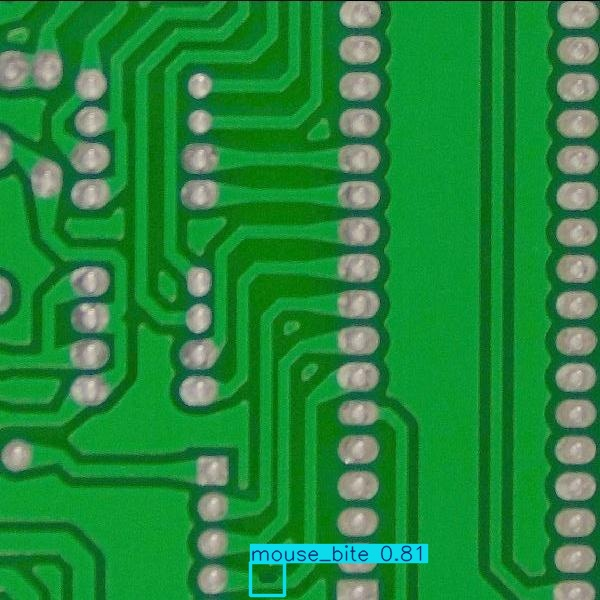

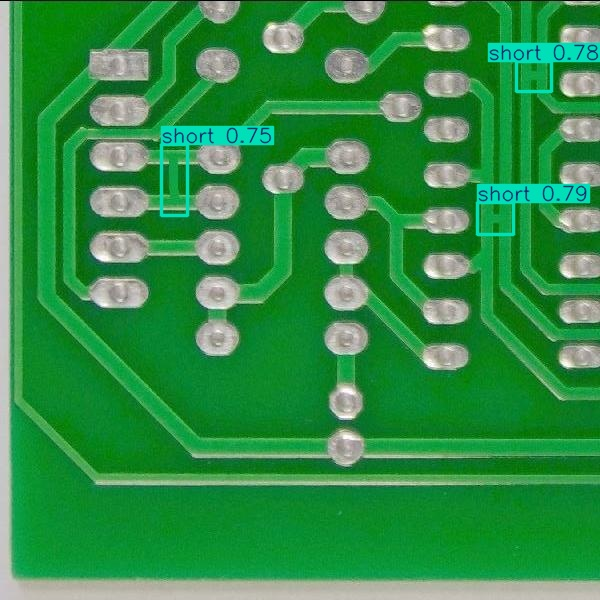

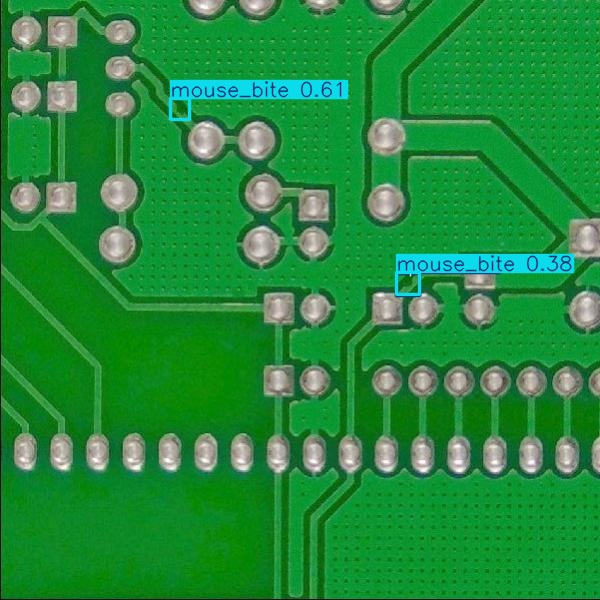

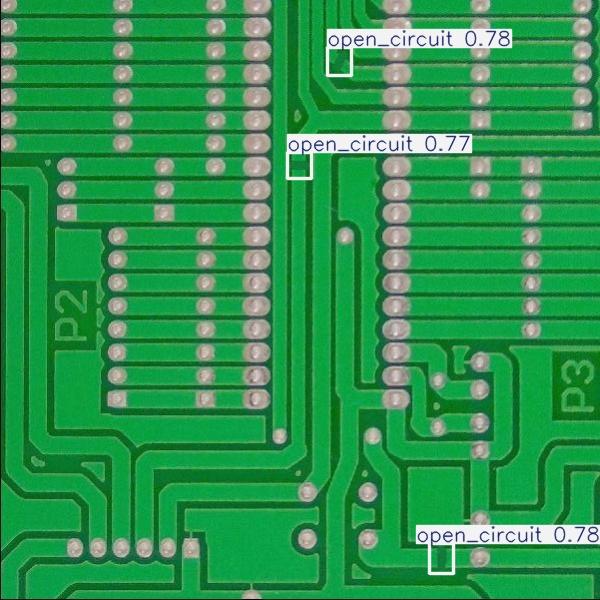

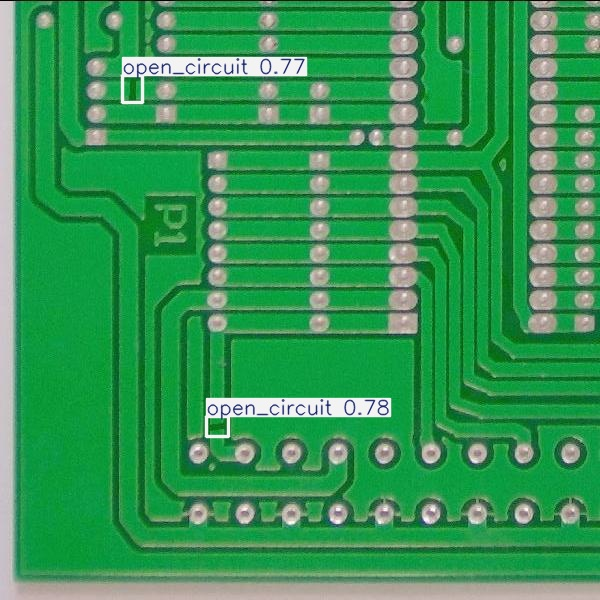

In [ ]:
from IPython.display import Image, display
import glob

prediction_imgs = glob.glob('/content/runs/detect/test_predictions/*.jpg')
for img in prediction_imgs:
    display(Image(img, width=600))

In [ ]:
import shutil
shutil.make_archive('/content/pcb_results', 'zip', '/content/runs/detect')

'/content/pcb_results.zip'

In [ ]:
from google.colab import files
files.download('/content/pcb_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>